# LSTM based longitudinal car following model 

In [2]:
import os 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import glob

In [3]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import GRU
from tensorflow.keras.optimizers import Adam

In [4]:
from keras_self_attention import SeqSelfAttention

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid

In [6]:
os.chdir("C:\\Users\\HP\\Desktop\\Research")

first we will consider about longitudinal and then focus on lateral.. 

## Data Selection 

the leaders-subject-followers pairs are taken to a list of dataframes 

In [7]:
# Define the path to the directory containing the CSV files
path = 'data\\milano\\'  # Use forward slashes or double backslashes for Windows paths

# Use glob to get all the CSV files in the directory
all_files = glob.glob(path + "leader_follower_pair_*.csv")

# Initialize an empty list to hold individual DataFrames
dfs = []

# Loop over the list of files and read each into a DataFrame, then append to the list
for filename in all_files:
    df = pd.read_csv(filename)
    dfs.append(df)

## Feature Selection 

We need to think of the variables from IDM, and other literature. 

possible variables. 

1. gap
2. relative speed
3. position
4. acceleration 
5. flw_type

dependet variable 
1. we want the position because it has less errors. 

#### variable sets to test

1. positional information 
2. positional information + relative speed
3. positional information + relative speed + acceleartion 
4. positional information + relative speed + gap + acceleration 

In [8]:
def relative_feature_adding(dataframe): 
    
    ## taking the relative features.
    """ This function is added within the create_sequences_for_pairs function """
    
    # add the new variables to the df 
    new_columns = ["Rel_xrot_1","Rel_xrot_2","Rel_xrot_3","Rel_xrot_4","Rel_xrot_5","Rel_xrot_6", "Rel_Speed_1",  "Rel_Speed_2",  "Rel_Speed_3",  "Rel_Speed_4", "Rel_Speed_5", "Rel_Speed_6"]

    dataframe[new_columns] = np.nan

    for idx, row in dataframe.iterrows():
        
        dataframe.at[idx, 'Rel_x[m]_1'] = row['x_rot_1'] - row['x_rot']
        dataframe.at[idx, 'Rel_x[m]_2'] = row['x_rot_2'] - row['x_rot']
        dataframe.at[idx, 'Rel_x[m]_3'] = row['x_rot_3'] - row['x_rot']
        dataframe.at[idx, 'Rel_x[m]_4'] = row['x_rot_4'] - row['x_rot']
        dataframe.at[idx, 'Rel_x[m]_5'] = row['x_rot_5'] - row['x_rot']
        dataframe.at[idx, 'Rel_x[m]_6'] = row['x_rot_6'] - row['x_rot']
    
        dataframe.at[idx, 'Rel_Speed_1'] = row['Speed [km/h]'] - row['Speed [km/h]_1']
        dataframe.at[idx, 'Rel_Speed_2'] = row['Speed [km/h]'] - row['Speed [km/h]_2']
        dataframe.at[idx, 'Rel_Speed_3'] = row['Speed [km/h]'] - row['Speed [km/h]_3']
        dataframe.at[idx, 'Rel_Speed_4'] = row['Speed [km/h]'] - row['Speed [km/h]_4']
        dataframe.at[idx, 'Rel_Speed_5'] = row['Speed [km/h]'] - row['Speed [km/h]_5']
        dataframe.at[idx, 'Rel_Sp#eed_6'] = row['Speed [km/h]'] - row['Speed [km/h]_6']


    return dataframe


In [7]:
def presence_adding(df): 

    # add new variables 
    new_columns = ['p1','p2', 'p3','p4','p5','p6']
    df[new_columns] = np.nan
    
    for index, row in df.iterrows(): 

        if row['x_rot_1'] is not None: 
            row.p1 = 1 
            
        if row['x_rot_2'] is not None: 
            row.p2 = 1 

        if row['x_rot_3'] is not None: 
            row.p3 = 1 

        if row['x_rot_4'] is not None: 
            row.p4 = 1 

        if row['x_rot_5'] is not None: 
            row.p5 = 1

        if row['x_rot_6'] is not None: 
            row.p6 = 1

    return df
    

In [10]:
# adding the relative variables 
for df in dfs: 
    df = relative_feature_adding(df)

In [87]:
# adding the presence variables 
for df in dfs: 
    df = presence_adding(df)

In [ ]:
# manual label encoding 
for df in dfs:
    df.replace('Car', 1, inplace = True)
    df.replace('Heavy Vehicle', 2, inplace = True)
    df.replace('Medium Vehicle', 3, inplace = True)
    df.replace('Motorcycle', 4, inplace = True)

In [ ]:
# one hot encoding for the flow type

one_hot_all_columns = ['flw_type_Car', 'flw_type_Heavy Vehicle', 'flw_type_Medium Vehicle', 'flw_type_Motorcycle',
               'flw_type_1_Car', 'flw_type_1_Heavy Vehicle', 'flw_type_1_Medium Vehicle', 'flw_type_1_Motorcycle',
               'flw_type_2_Car', 'flw_type_2_Heavy Vehicle', 'flw_type_2_Medium Vehicle', 'flw_type_2_Motorcycle',
               'flw_type_3_Car', 'flw_type_3_Heavy Vehicle', 'flw_type_3_Medium Vehicle', 'flw_type_3_Motorcycle',
               'flw_type_4_Car', 'flw_type_4_Heavy Vehicle', 'flw_type_4_Medium Vehicle', 'flw_type_4_Motorcycle',
               'flw_type_5_Car', 'flw_type_5_Heavy Vehicle', 'flw_type_5_Medium Vehicle', 'flw_type_5_Motorcycle',
               'flw_type_6_Car', 'flw_type_6_Heavy Vehicle', 'flw_type_6_Medium Vehicle', 'flw_type_6_Motorcycle']


before_dfs = dfs 
dfs = []
for df in before_dfs: 
    df = pd.get_dummies(df, columns=['flw_type','flw_type_1','flw_type_2','flw_type_3','flw_type_4','flw_type_5','flw_type_6'])
    df[list(set(one_hot_all_columns) - set(list(df.filter(regex='flw_type').columns)))] = np.nan
    dfs.append(df)

In [11]:
# replace all the null values to 0 
for df in dfs: 
    df.fillna(0, inplace=True)

In [12]:
# all x and y positions 
#feature_list = ['x_rot', 'y_rot', 'x_rot_1', 'y_rot_1', 'x_rot_2', 'y_rot_2', 'x_rot_3', 'y_rot_3',  'x_rot_4', 'y_rot_4', 'x_rot_5', 'y_rot_5', 'x_rot_6', 'y_rot_6']

# all x positions 
#feature_list = ['x_rot', 'x_rot_1', 'x_rot_2','x_rot_3', 'x_rot_4', 'x_rot_5', 'x_rot_6']

# only subject x positions 
#feature_list = ['x_rot']

# only subject x position and speed 
#feature_list = ['x_rot', 'Speed [km/h]']

# all x positions and longitudial speeds 
#feature_list = ['x_rot', 'x_rot_1', 'x_rot_2','x_rot_3', 'x_rot_4', 'x_rot_5', 'x_rot_6', 'Speed [km/h]', 'Speed [km/h]_1', 'Speed [km/h]_2', 'Speed [km/h]_3', 'Speed [km/h]_4', 'Speed [km/h]_5', 'Speed [km/h]_6']

# x positions and speeds of leaders 
#feature_list = ['x_rot', 'x_rot_1', 'x_rot_2','x_rot_3', 'Speed [km/h]', 'Speed [km/h]_1', 'Speed [km/h]_2', 'Speed [km/h]_3']

# only the relative values 
#feature_list = ['Rel_x[m]_1','Rel_x[m]_2','Rel_x[m]_3','Rel_x[m]_4','Rel_x[m]_5','Rel_x[m]_6', 'Rel_Speed_1', 'Rel_Speed_2','Rel_Speed_3','Rel_Speed_4','Rel_Speed_5','Rel_Speed_6']

# relative values and distinct speed values 
#feature_list = ['Rel_x[m]_1','Rel_x[m]_2','Rel_x[m]_3','Rel_x[m]_4','Rel_x[m]_5','Rel_x[m]_6', 'Rel_Speed_1', 'Rel_Speed_2','Rel_Speed_3','Rel_Speed_4','Rel_Speed_5','Rel_Speed_6', 'Speed [km/h]', 'Speed [km/h]_1', 'Speed [km/h]_2', 'Speed [km/h]_3', 'Speed [km/h]_4', 'Speed [km/h]_5', 'Speed [km/h]_6']

# relative values and distinct positional values 
feature_list = ['Rel_x[m]_1','Rel_x[m]_2','Rel_x[m]_3','Rel_x[m]_4','Rel_x[m]_5','Rel_x[m]_6', 'Rel_Speed_1', 'Rel_Speed_2','Rel_Speed_3','Rel_Speed_4','Rel_Speed_5','Rel_Speed_6', 'x_rot', 'x_rot_1', 'x_rot_2','x_rot_3', 'x_rot_4', 'x_rot_5', 'x_rot_6']

# the relative positions, gap and speed. and static positions and speed 
#feature_list = ['Rel_x[m]_1','Rel_x[m]_2','Rel_x[m]_3','Rel_x[m]_4','Rel_x[m]_5','Rel_x[m]_6', 'Rel_Speed_1', 'Rel_Speed_2','Rel_Speed_3','Rel_Speed_4','Rel_Speed_5','Rel_Speed_6', 'x_rot', 'x_rot_1', 'x_rot_2','x_rot_3', 'x_rot_4', 'x_rot_5', 'x_rot_6',  'Speed [km/h]', 'Speed [km/h]_1', 'Speed [km/h]_2', 'Speed [km/h]_3', 'Speed [km/h]_4', 'Speed [km/h]_5', 'Speed [km/h]_6']

# the relative positions, speed and accelerations 
#feature_list = ['Rel_x[m]_1','Rel_x[m]_2','Rel_x[m]_3','Rel_x[m]_4','Rel_x[m]_5','Rel_x[m]_6', 'Rel_Speed_1', 'Rel_Speed_2','Rel_Speed_3','Rel_Speed_4','Rel_Speed_5','Rel_Speed_6', 'x_rot', 'x_rot_1', 'x_rot_2','x_rot_3', 'x_rot_4', 'x_rot_5', 'x_rot_6',  'Speed [km/h]', 'Speed [km/h]_1', 'Speed [km/h]_2', 'Speed [km/h]_3', 'Speed [km/h]_4', 'Speed [km/h]_5', 'Speed [km/h]_6', 'Tan. Acc. [ms-2]','Tan. Acc. [ms-2]_1','Tan. Acc. [ms-2]_2','Tan. Acc. [ms-2]_3','Tan. Acc. [ms-2]_4','Tan. Acc. [ms-2]_5','Tan. Acc. [ms-2]_6']

# the relative positions , gap and speed. and static positions, speed and the vehicle type 
#feature_list = ['Rel_x[m]_1','Rel_x[m]_2','Rel_x[m]_3','Rel_x[m]_4','Rel_x[m]_5','Rel_x[m]_6', 'Rel_Speed_1', 'Rel_Speed_2','Rel_Speed_3','Rel_Speed_4','Rel_Speed_5','Rel_Speed_6', 'x_rot', 'x_rot_1', 'x_rot_2','x_rot_3', 'x_rot_4', 'x_rot_5', 'x_rot_6',  'Speed [km/h]', 'Speed [km/h]_1', 'Speed [km/h]_2', 'Speed [km/h]_3', 'Speed [km/h]_4', 'Speed [km/h]_5', 'Speed [km/h]_6', 
#               'flw_type','flw_type_1','flw_type_2','flw_type_3','flw_type_4','flw_type_5','flw_type_6']


# the relative positions , gap and speed. and static positions, speed and the vehicle type one hot encoded  
#feature_list = ['Rel_x[m]_1','Rel_x[m]_2','Rel_x[m]_3','Rel_x[m]_4','Rel_x[m]_5','Rel_x[m]_6', 'Rel_Speed_1', 'Rel_Speed_2','Rel_Speed_3','Rel_Speed_4','Rel_Speed_5','Rel_Speed_6', 'x_rot', 'x_rot_1', 'x_rot_2','x_rot_3', 'x_rot_4', 'x_rot_5', 'x_rot_6',  'Speed [km/h]', 'Speed [km/h]_1', 'Speed [km/h]_2', 'Speed [km/h]_3', 'Speed [km/h]_4', 'Speed [km/h]_5', 'Speed [km/h]_6', 
#               'flw_type_Car', 'flw_type_Heavy Vehicle', 'flw_type_Medium Vehicle', 'flw_type_Motorcycle',
#               'flw_type_1_Car', 'flw_type_1_Heavy Vehicle', 'flw_type_1_Medium Vehicle', 'flw_type_1_Motorcycle',
#               'flw_type_2_Car', 'flw_type_2_Heavy Vehicle', 'flw_type_2_Medium Vehicle', 'flw_type_2_Motorcycle',
#               'flw_type_3_Car', 'flw_type_3_Heavy Vehicle', 'flw_type_3_Medium Vehicle', 'flw_type_3_Motorcycle',
#               'flw_type_4_Car', 'flw_type_4_Heavy Vehicle', 'flw_type_4_Medium Vehicle', 'flw_type_4_Motorcycle',
#               'flw_type_5_Car', 'flw_type_5_Heavy Vehicle', 'flw_type_5_Medium Vehicle', 'flw_type_5_Motorcycle',
#               'flw_type_6_Car', 'flw_type_6_Heavy Vehicle', 'flw_type_6_Medium Vehicle', 'flw_type_6_Motorcycle']


## Modelling 

### Pre process the data 

The data should be created in a sequence manner to use in the LSTM model. The following two functions are used to that. 

The sequences are created for pairs seperatly, because each pair has distinct behaviors. A single combined dataframe cannot be used because the X values may contain the information of another pair for a paticular y value. 

The feature transformation/scalling is performed within the function create sequence for pairs 


In [13]:
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

In [14]:
# custom function to create the sequences  
def create_sequences(features, target, seq_length):
    xs, ys = [], []
    for i in range(len(features) - seq_length):
        x = features[i:i+seq_length]
        y = target[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [15]:
# Function to create sequences for each pair separately
# The feature scalling is also performed within, treating each pair uniquely. 
def create_sequences_for_pairs(pairs_data, seq_length, feature_list, scaler_features, scaler_target):
    X, y = [], []
    for df in pairs_data:
        
        features = df[feature_list].values
        target = df['x_rot'].values
        features_scaled =  scaler_features.fit_transform(features)  
        target_scaled = scaler_target.fit_transform(target.reshape(-1, 1))
        xs, ys = create_sequences(features_scaled, target_scaled, seq_length)
        X.append(xs)
        y.append(ys)
        
    return np.concatenate(X), np.concatenate(y)

In [35]:
# Define sequence length
seq_length = 10

# set the length of the data to use 
dfs_new = dfs[:240]

# make the pairs
X, y = create_sequences_for_pairs(dfs_new, seq_length,  feature_list, scaler_features, scaler_target)

# fill the null values to 0 
X = np.nan_to_num(X, nan = 0)
y = np.nan_to_num(y, nan = 0)

the train test split should perform after making the sequence pairs because it shuffles the data. if it is made before the sequence making incorrect information will be in the sequences 

In [36]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
X_train.shape

(212076, 10, 19)

In [38]:
y_train.shape

(212076, 1)

### Build the LSTM Model

workflow 

take the relative speed and positions (gap) and measure the impact of features
try the impact of additional variable towards teh presentce of the vehicles has any impact. 
take the impact of the vehicle type
and finally select the features that we want. for the longitudinal 

extend towards the lateral posotion as well. 
and select the features 

hyper parameter optimization and LSTM model finalization. 

compare the simulation with the IDM. lane changing behavior as well. 

parameters to change to test 

seq length 
LSTM units per layer 
number of LSTM units 
other set of regulization methods like drop out etc. 
batch size 
number of epoches
learning rate. 


### visualize for real roads approach 

In [155]:
x_values_predicted = predictions_rescaled[5500:] 
x_transformed = scaler_target.inverse_transform(y_test)[5500:]
x_values1 = dfs[314].x_rot
x_values = x_values1[len(x_values1)-len(x_values_predicted):]
y_values = dfs[314].y_rot
y_values = y_values[len(x_values1)-len(x_values_predicted):]

In [139]:
len(x_values_predicted), len(y_values)

(995, 995)

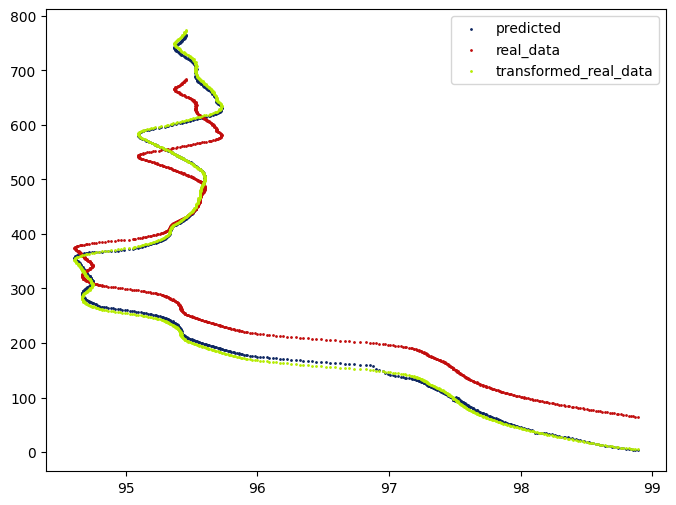

In [156]:
plt.figure(figsize=(8, 6))

plt.scatter(y_values, x_values_predicted, color='#0D2661', s=1, label = 'predicted')
plt.scatter(y_values, x_values, color='#C10D0D', s=1 , label = 'real_data')
plt.scatter(y_values, x_transformed, color='#B6EC03', s=1, label = 'transformed_real_data')
plt.legend()
plt.show()

#############################################
### Accuracy report 
#############################################

for 30 datasets
 - with only x related positions 
Test Loss: 0.0009779518004506826
-  with both x and y related positions 
Test Loss: 0.0010932201985269785
- only subject vehicle x positions 
Test Loss: 0.006079832091927528
- only subject vehicle x position and speed 
Test Loss: 0.0010679749539121985
- with all x positions and longitudianl speed. 
Test Loss: 0.0028918811585754156
- with x and speed of the leaders (veh 1, 2, 3) and subject 
Test Loss: 0.0012857422698289156
- with relative x and speed values 
Test Loss: 0.000443809840362519
Test Loss: 0.0002170595107600093
Test Loss: 0.00007717358676018193e
Test Loss: 0.0001957150234375149 (for 20 epoches )
- with relative x and speed values and p values
Test Loss: 0.000190590915735811 (for 20 epoches), with the use of p values, no use.
- with relative x and speed values and distinct position and speed values 
Test Loss: 0.00001689588862063829
Test Loss: 0.0000072179705057351384
Test Loss: 0.000004192713731754338
for bidirectional
Test Loss: 2.320374005648773e-05

(for 20 epoches)
Test Loss: 0.000005991584657749627 



- with relative x and speed values and distinct speed values 
Test Loss: 0.00047027747496031225

- with relative x and speed values and distinct positions
Test Loss: 0.000021659427147824317
Test Loss: 0.00002165331898140721
Test Loss: 0.000007162363999668742 (with 200 LSTM units)
Test Loss: 0.000013952521840110421
Test Loss: 0.000010547199053689837
Test Loss: 0.00004563251422950998
Test Loss: 0.00003078419103985652 (with 500 units)
Test Loss: 4.398036708153086e-06 (with sequence length of 50)




- with relative x and speed values and distinct position, speed, acceleration 
Test Loss: 0.000015665496903238818
- with relative x and speed values and distinct position and speed values , flw type  # label encoding 
Test Loss: 0.00003799903788603842
- with relative x and speed values and distinct position and speed values , flw type  # one hot encoding 
Test Loss: 0.000021203943106229417
Test Loss: 0.0000225960866373498 # replacing the null values to 0 






## LSTM Model 

In [39]:
X_train.shape

(212076, 10, 19)

In [42]:
# Define the LSTM model
# model = Sequential()
# model.add(LSTM(100, activation='relu', return_sequences= True,  input_shape=(seq_length, X_train.shape[2])))
# model.add(LSTM(100, activation='relu'))
# model.add(Dense(1))

# Define the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(seq_length, X_train.shape[2])))
model.add(Dense(1))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error')


# Display the model summary
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                       │ (None, 128)                 │          75,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 75,905 (296.50 KB)

 Trainable params: 75,905 (296.50 KB)

 Non-trainable params: 0 (0.00 B)

### Train and Predict

Epoch 1/10
10604/10604 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - loss: 0.0038 - val_loss: 1.0774e-05
Epoch 2/10
10604/10604 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - loss: 1.3150e-05 - val_loss: 1.0042e-05
Epoch 3/10
10604/10604 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - loss: 6.9304e-06 - val_loss: 2.7709e-06
Epoch 4/10
10604/10604 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - loss: 4.8756e-06 - val_loss: 3.3450e-06
Epoch 5/10
10604/10604 ━━━━━━━━━━━━━━━━━━━━ 47s 4ms/step - loss: 3.8201e-06 - val_loss: 2.4282e-06
Epoch 6/10
10604/10604 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - loss: 3.3287e-06 - val_loss: 1.1489e-06
Epoch 7/10
10604/10604 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - loss: 2.3440e-06 - val_loss: 9.2587e-07
Epoch 8/10
10604/10604 ━━━━━━━━━━━━━━━━━━━━ 48s 4ms/step - loss: 2.2717e-06 - val_loss: 6.2215e-07
Epoch 9/10
10604/10604 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - loss: 1.9901e-06 - val_loss: 1.1711e-06
Epoch 10/10
10604/10604 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - loss: 1.7472e-06 - val_loss: 2.3014e-06


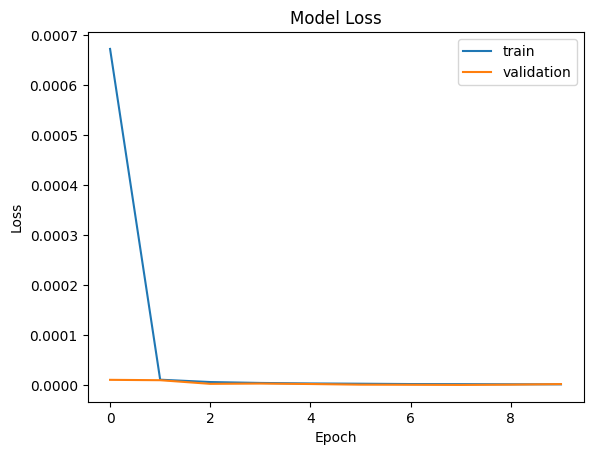

In [43]:
# Train the model for 10 epochs
trained_model = model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2)

# Plot the training loss
plt.plot(trained_model.history['loss'], label='train')
plt.plot(trained_model.history['val_loss'], label='validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Test Loss: 2.302721895830473e-06
1657/1657 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


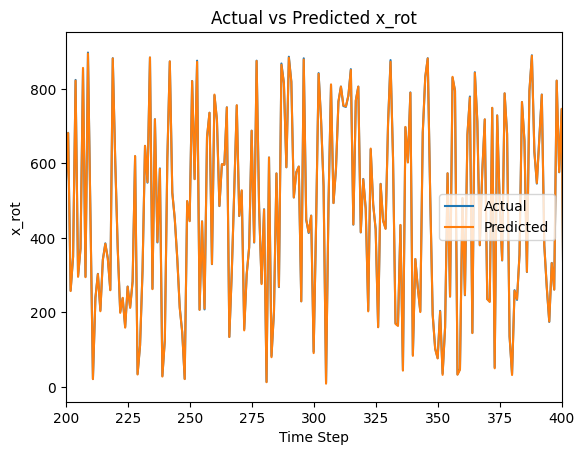

In [46]:
# Evaluate the model on the test data
loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {loss}')

# Making predictions
predictions = model.predict(X_test)

# Inverse transform the predictions to get the original scale
predictions_rescaled = scaler_target.inverse_transform(predictions)

# Plot the predictions vs actual values
plt.plot(scaler_target.inverse_transform(y_test), label='Actual')
plt.plot(predictions_rescaled, label='Predicted')
plt.title('Actual vs Predicted x_rot')
plt.xlabel('Time Step')
plt.ylabel('x_rot')
plt.xlim(200, 400)  # Limit the x-axis to the first 1000 points
plt.legend()
plt.show()

In [ ]:
deviation plot 

## Hyperparameter Optimization 

### Learning rate

In [20]:
# Define a grid of learning rates to search
param_grid = {'learning_rate': [1e-1, 1e-2, 1e-3, 1e-4]}

best_lr = None
best_mse = float('inf')

seq_length = 10

In [ ]:
for params in ParameterGrid(param_grid):
    
    learning_rate = params['learning_rate']
    
    # Create and compile the model
    model = Sequential()
    model.add(LSTM(200, input_shape=(seq_length, X_train.shape[2])))
    model.add(Dense(1))
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    # Train the model
    trained_model = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
    
    # Evaluate the model
    mse = model.evaluate(X_test, y_test, verbose=0)

    print(mse)
    
    if mse < best_mse:
        best_mse = mse
        best_lr = learning_rate

print(f'Best Learning Rate: {best_lr}')

### Batch Size 

In [22]:
# Define a grid of batch sizes to search
param_grid = {'batch_size': [16, 32, 64, 128]}

best_bs = None
best_mse = float('inf')

seq_length = 10

In [24]:
for params in ParameterGrid(param_grid):
    
    batch_size = params['batch_size']
    
    # Create and compile the model
    model = Sequential()
    model.add(LSTM(200, input_shape=(seq_length, X_train.shape[2])))
    model.add(Dense(1))
    
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    # Train the model
    trained_model = model.fit(X_train, y_train, epochs=10, batch_size=batch_size, validation_split=0.2)
    
    # Evaluate the model
    mse = model.evaluate(X_test, y_test, verbose=0)

    print(mse)
    
    if mse < best_mse:
        best_mse = mse
        best_bs = batch_size

print(f'Best Batch Size: {best_bs}')

Epoch 1/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0094 - val_loss: 1.5466e-04
Epoch 2/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 1.1300e-04 - val_loss: 5.6988e-05
Epoch 3/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 5.2714e-05 - val_loss: 2.9727e-05
Epoch 4/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 2.7823e-05 - val_loss: 5.1779e-05
Epoch 5/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 2.3236e-05 - val_loss: 2.7637e-05
Epoch 6/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 1.9653e-05 - val_loss: 8.6201e-06
Epoch 7/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1.2473e-05 - val_loss: 9.0097e-06
Epoch 8/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 1.1817e-05 - val_loss: 4.1231e-06
Epoch 9/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 1.1605e-05 - val_loss: 3.1144e-06
Epoch 10/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 7.8976e-06 - val_loss: 2.7932e-06
2.932993311333121e-06
Epoch 1/10
650/650

### The number of units 

In [20]:
# Define a grid of batch sizes to search
param_grid = {'no_of_units': [32, 64, 128, 256, 512]}

best_bs = None
best_mse = float('inf')

seq_length = 10

In [21]:
for params in ParameterGrid(param_grid):
    
    no_of_units = params['no_of_units']
    
    # Create and compile the model
    model = Sequential()
    model.add(LSTM(no_of_units, input_shape=(seq_length, X_train.shape[2])))
    model.add(Dense(1))
    
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    # Train the model
    trained_model = model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2)
    
    # Evaluate the model
    mse = model.evaluate(X_test, y_test, verbose=0)

    print(mse)
    
    if mse < best_mse:
        best_mse = mse
        best_no_of_units = no_of_units

print(f'Best no_of_units: {best_no_of_units}')

Epoch 1/10


C:\Users\HP\anaconda33\envs\cfmodels\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1299/1299 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0758 - val_loss: 0.0016
Epoch 2/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0011 - val_loss: 5.6781e-04
Epoch 3/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.9017e-04 - val_loss: 3.6981e-04
Epoch 4/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3.2856e-04 - val_loss: 2.4841e-04
Epoch 5/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.3794e-04 - val_loss: 1.7763e-04
Epoch 6/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.7125e-04 - val_loss: 1.4341e-04
Epoch 7/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.3141e-04 - val_loss: 9.7705e-05
Epoch 8/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9.7810e-05 - val_loss: 7.9348e-05
Epoch 9/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.4017e-05 - val_loss: 5.9278e-05
Epoch 10/10
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 6.0738e-05 - val_loss: 4.8361e-05
5.007736399420537e-05
Epoch 1/10
1299/1299 ━━━━━━━━━━━━━━━━━━━

## Ensemble LSTM Model 

We use the varying training data ensemble model because we do not find a reason to change the model or hyperparameters. This is done to reduce the variance of the testing MSE which gives different results based on 
randomized weight initialization. 

Bootstrap sampling is used to make datasets. other method is random picking, we did not used that here. 

In [22]:
def create_model(input_shape):
    
    model = Sequential()
    model.add(LSTM(128, input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error')

    return model

In [23]:
def bootstrap_sample(X, y):
    indices = np.random.choice(len(X), len(X), replace=True)
    return X[indices], y[indices]

In [24]:
def predict_ensemble(models, X):
    predictions = np.zeros((X.shape[0], len(models)))
    for i, model in enumerate(models):
        predictions[:, i] = model.predict(X).flatten()
    return np.mean(predictions, axis=1)

In [25]:
num_models = 5
models = []

for _ in range(num_models):
    X_bootstrap, y_bootstrap = bootstrap_sample(X_train, y_train)
    model = create_model(input_shape=(seq_length, X_train.shape[2]))
    model.fit(X_bootstrap, y_bootstrap, epochs=10, batch_size=16, verbose=0)
    models.append(model)

In [26]:
# Predict and evaluate
y_pred = predict_ensemble(models, X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error of the ensemble model: {mse}')

203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Mean Squared Error of the ensemble model: 3.3319267734133803e-06


## Comparision with Simulation Results 

### Visulaize against lateral cordiantes

In [32]:
### predict for the real world data sample 

sample_df_s = dfs[274]

lat_values = sample_df_s['y_rot']

scaler_features_s = MinMaxScaler()
scaler_target_s = MinMaxScaler()

features_scaled_s =  scaler_features_s.fit_transform(sample_df_s[feature_list].values)  
target_scaled_w = scaler_target_s.fit_transform(sample_df_s['x_rot'].values.reshape(-1, 1))

x_sample, y_sample = create_sequences(features_scaled_s,  target_scaled_w, 10)
predicted_values = predict_ensemble(models, x_sample)
predicted_values_scaled = scaler_target_s.inverse_transform(predicted_values.reshape(-1, 1)) #for the use of a single model, do not add reshape part. 
transformed_y_values = scaler_target_s.inverse_transform(target_scaled_w)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


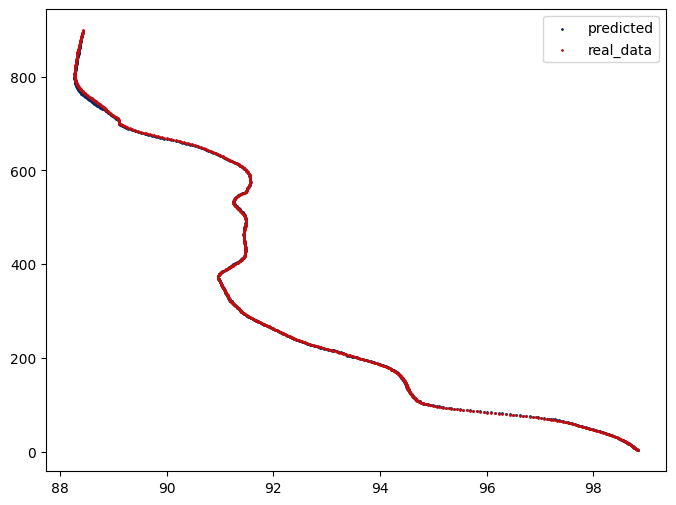

In [33]:
#real world plot relating to the lateral position 
plt.figure(figsize=(8, 6))

plt.scatter(lat_values[10:], predicted_values_scaled, color='#0D2661', s=1, label = 'predicted')
plt.scatter(lat_values[10:], sample_df_s['x_rot'][10:], color='#C10D0D', s=1 , label = 'real_data')
#plt.scatter(lat_values, transformed_y_values, color='#B6EC03', s=1, label = 'transformed_real_data')
plt.legend()
plt.savefig('vehilce245.jpg')
plt.show()

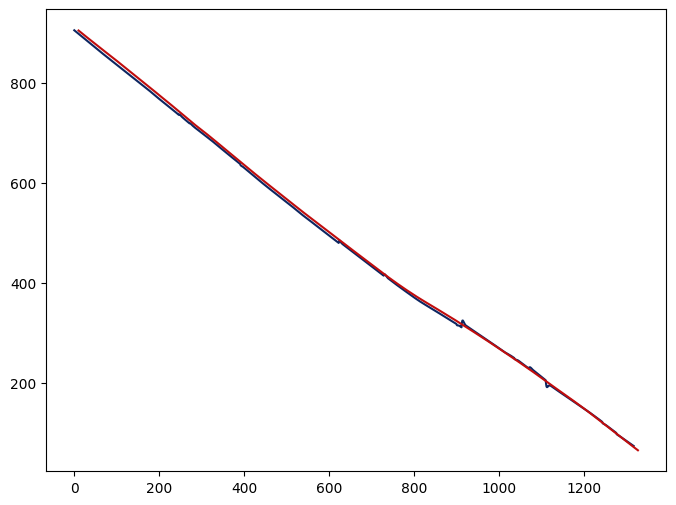

In [229]:
# change of x position with time 
plt.figure(figsize=(8, 6))
plt.plot(predicted_values_scaled, color='#0D2661', label = 'predicted')
plt.plot(sample_df_s['x_rot'][10:], color='#C10D0D', label = 'real_data')

### Gap test

#### LSTM model 

In [44]:
dfs_for_test = dfs[260:]

3.4049761024235577e-25

array([913.36802133, 913.04156069, 912.72851138, ...,  18.98411634,
        18.74709836,  18.50559302])

In [65]:
error_list = []

for df in dfs_for_test: 

    scaler_features_s = MinMaxScaler()
    scaler_target_s = MinMaxScaler()
    
    features_scaled_s =  scaler_features_s.fit_transform(df[feature_list].values)  
    target_scaled_w = scaler_target_s.fit_transform(df['x_rot'].values.reshape(-1, 1))
    
    x_sample, y_sample = create_sequences(features_scaled_s,  target_scaled_w, 10)
   # predicted_values = predict_ensemble(models, x_sample)

    predicted_values = model.predict(x_sample)
    
    predicted_values_scaled = scaler_target_s.inverse_transform(predicted_values.reshape(-1, 1)) #for the use of a single model, do not add reshape part. 
    transformed_y_values = scaler_target_s.inverse_transform(target_scaled_w)

    sse = sum((df['x_rot'].values - transformed_y_values.ravel())**2)
    mse = np.sqrt(sse/df.shape[0])

    error_list.append(mse)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
28/28 ━━━━━━━━━━━━━━━━━━━

In [69]:
sum(error_list)/len(dfs_for_test)

1.4211915207922454e-14

#### IDM model 

In [ ]:
sim(25, 0.8 , 0.5 , 2, 2, data, IDM)

## Notes 

In [ ]:
replace the null values with 0 and check for the accuracy. 

as per now our conclusion regarding the features for modelling 

relative speed posistion + distinct positions are also good. (without the speed values), this one is selected. 

It was noted that when implimented seperately, for simple models the GRU and LSTM models both behaves similarly. 

next step is to ensemble the LSTM model in order to reduce the randomiation variance. we do not see the use of 
model ensembling as all the models perform in a similar way. 


    7/24 
- try to further improve the LSTM model with available any other techniques. 
- try to impliment an early stopping criteria rather than number of epoches. 


